In [1]:
!pip install tensorflow

   ---------------------------------------- 0.0/384.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/384.1 MB 3.8 MB/s eta 0:01:42
   ---------------------------------------- 1.6/384.1 MB 4.2 MB/s eta 0:01:31
   ---------------------------------------- 2.6/384.1 MB 4.5 MB/s eta 0:01:25
   ---------------------------------------- 3.7/384.1 MB 4.6 MB/s eta 0:01:24
   ---------------------------------------- 4.7/384.1 MB 4.8 MB/s eta 0:01:19
    --------------------------------------- 5.8/384.1 MB 5.0 MB/s eta 0:01:16
    --------------------------------------- 6.6/384.1 MB 4.6 MB/s eta 0:01:22
    --------------------------------------- 7.6/384.1 MB 4.8 MB/s eta 0:01:19
    --------------------------------------- 9.2/384.1 MB 5.0 MB/s eta 0:01:15
   - -------------------------------------- 10.0/384.1 MB 5.0 MB/s eta 0:01:15
   - -------------------------------------- 11.0/384.1 MB 5.0 MB/s eta 0:01:15
   - -------------------------------------- 11.8/384.1 MB 5.0 MB/s et

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


In [2]:
df = pd.read_csv(
    r"C:\Users\asus\Downloads\KNN\Career_Nova_Final_Clean_Optimized_Dataset.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (1016, 19)


In [3]:
features = [
    "Job_Zone",
    "essential_skill_count",
    "avg_essential_importance",
    "max_essential_importance",
    "software_skill_count",
    "hot_technology_count",
    "in_demand_software_count",
    "has_job_zone",
    "has_essential_skills",
    "has_software_skills",
    "data_completeness_pct"
]

X = df[features].copy()

print(X.shape)
print(X.head())

(1016, 11)
   Job_Zone  essential_skill_count  avg_essential_importance  \
0       4.0                      1                      3.16   
1       2.0                      1                      2.84   
2       4.0                      1                      3.53   
3       5.0                      1                      3.09   
4       4.0                      1                      3.77   

   max_essential_importance  software_skill_count  hot_technology_count  \
0                      3.88                     1                     1   
1                      4.00                     1                     1   
2                      4.38                     1                     1   
3                      3.88                     1                     1   
4                      4.12                     1                     1   

   in_demand_software_count  has_job_zone  has_essential_skills  \
0                         1             1                     1   
1                  

In [4]:
for column in features:
    X[column] = pd.to_numeric(X[column], errors="coerce")

In [5]:
X = X.fillna(X.median())

print("Missing values:")
print(X.isnull().sum())

Missing values:
Job_Zone                    0
essential_skill_count       0
avg_essential_importance    0
max_essential_importance    0
software_skill_count        0
hot_technology_count        0
in_demand_software_count    0
has_job_zone                0
has_essential_skills        0
has_software_skills         0
data_completeness_pct       0
dtype: int64


In [6]:
y = df["Job_Zone"]

In [7]:
print(y.value_counts().sort_index())

Job_Zone
2.0    337
3.0    208
4.0    226
5.0    152
Name: count, dtype: int64


In [8]:
valid = y.notna()

X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (923, 11)
y shape: (923,)


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: [2. 3. 4. 5.]


In [10]:
num_classes = len(label_encoder.classes_)

y_categorical = to_categorical(
    y_encoded,
    num_classes=num_classes
)

print("Number of classes:", num_classes)

Number of classes: 4


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 738
Testing samples: 185


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
X_train_cnn = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_cnn = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("CNN training shape:", X_train_cnn.shape)
print("CNN testing shape:", X_test_cnn.shape)

CNN training shape: (738, 11, 1)
CNN testing shape: (185, 11, 1)


In [14]:
model = Sequential([
    
    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        input_shape=(X_train_cnn.shape[1], 1)
    ),
    
    MaxPooling1D(pool_size=2),
    
    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu"
    ),
    
    Flatten(),
    
    Dense(64, activation="relu"),
    
    Dropout(0.3),
    
    Dense(num_classes, activation="softmax")
])

C:\Users\asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 9, 32)               │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 4, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 2, 64)               │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,852 (58.02 KB)

 Trainable params: 14,852 (58.02 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN compiled successfully!")

CNN compiled successfully!


In [17]:
history = model.fit(
    X_train_cnn,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 150ms/step - accuracy: 0.5305 - loss: 1.2528 - val_accuracy: 0.5338 - val_loss: 1.0868
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6322 - loss: 0.9918 - val_accuracy: 0.7432 - val_loss: 0.8400
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7102 - loss: 0.7956 - val_accuracy: 0.7973 - val_loss: 0.6964
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7780 - loss: 0.6702 - val_accuracy: 0.8311 - val_loss: 0.5805
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8017 - loss: 0.5986 - val_accuracy: 0.8514 - val_loss: 0.4991
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8475 - loss: 0.5018 - val_accuracy: 0.8919 - val_loss: 0.4145
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8746 - loss: 0.4316 - val_accuracy: 0.9189 - val_loss: 0.3353
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9186 - loss: 0.3384 - val_accuracy: 0.9392 - 

In [18]:
test_loss, test_accuracy = model.evaluate(
    X_test_cnn,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Loss: 0.17520861327648163
Test Accuracy: 0.9783783555030823
Test Accuracy (%): 97.83783555030823


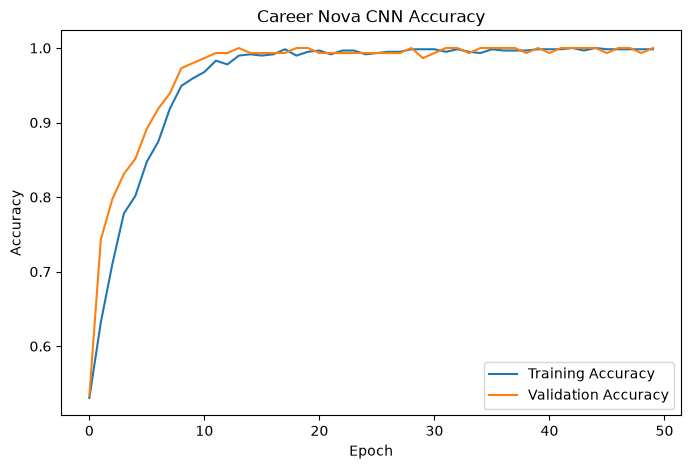

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Career Nova CNN Accuracy")

plt.legend()
plt.show()

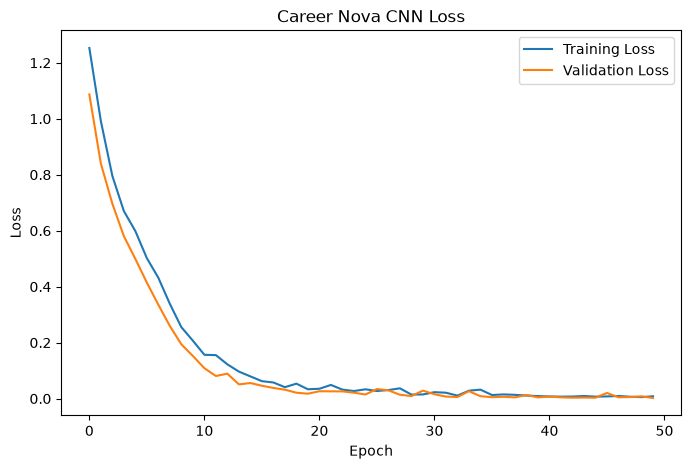

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Career Nova CNN Loss")

plt.legend()
plt.show()

In [21]:
y_probability = model.predict(X_test_cnn)

y_pred = np.argmax(
    y_probability,
    axis=1
)

y_actual = np.argmax(
    y_test,
    axis=1
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


In [22]:
predicted_job_zones = label_encoder.inverse_transform(y_pred)

actual_job_zones = label_encoder.inverse_transform(y_actual)

for actual, predicted in zip(
    actual_job_zones[:20],
    predicted_job_zones[:20]
):
    print(
        "Actual:", actual,
        "| Predicted:", predicted
    )

Actual: 2.0 | Predicted: 2.0
Actual: 4.0 | Predicted: 4.0
Actual: 3.0 | Predicted: 3.0
Actual: 2.0 | Predicted: 2.0
Actual: 2.0 | Predicted: 2.0
Actual: 2.0 | Predicted: 2.0
Actual: 4.0 | Predicted: 4.0
Actual: 4.0 | Predicted: 4.0
Actual: 4.0 | Predicted: 4.0
Actual: 2.0 | Predicted: 2.0
Actual: 3.0 | Predicted: 3.0
Actual: 2.0 | Predicted: 2.0
Actual: 3.0 | Predicted: 3.0
Actual: 5.0 | Predicted: 5.0
Actual: 3.0 | Predicted: 3.0
Actual: 2.0 | Predicted: 2.0
Actual: 2.0 | Predicted: 2.0
Actual: 4.0 | Predicted: 4.0
Actual: 3.0 | Predicted: 3.0
Actual: 2.0 | Predicted: 2.0


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_actual,
    y_pred
)

precision = precision_score(
    y_actual,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_actual,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_actual,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 50)
print("CAREER NOVA CNN RESULTS")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("=" * 50)

CAREER NOVA CNN RESULTS
Accuracy  : 0.9784
Precision : 0.9795
Recall    : 0.9784
F1 Score  : 0.9782


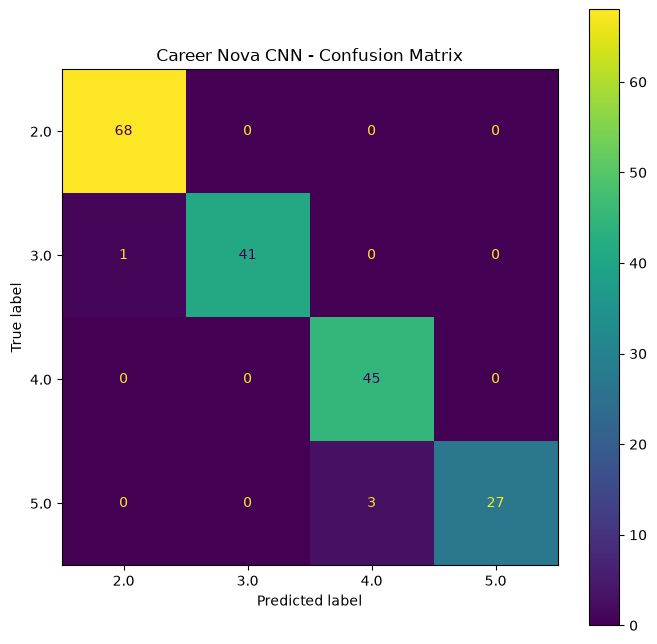

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_actual,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    ax=ax,
    values_format="d"
)

plt.title("Career Nova CNN - Confusion Matrix")
plt.show()